# 🎬 CT255H - Movie Recommendation System
## NexConflict - Hệ thống Đề xuất Phim sử dụng Machine Learning

---

**📚 Môn học:** CT255H - Nghiệp vụ thông minh (Business Intelligence)

**🏫 Trường:** Đại học Cần Thơ - Trường Công nghệ thông tin và Truyền Thông

**📅 Năm học:** 2024-2025

---

### 👥 Thành viên nhóm
| STT | Họ và Tên | MSSV |
|-----|-----------|------|
| 1 | Nguyễn Thành Trọng | B2305615 |
| 2 | Cao Tường Hưng | B2303873 |

---

### 📋 Mục lục
1. [Giới thiệu đề tài](#1-giới-thiệu-đề-tài)
2. [Dataset và Tiền xử lý](#2-dataset-và-tiền-xử-lý)
3. [Phương pháp Collaborative Filtering (SVD)](#3-collaborative-filtering-svd)
4. [Phương pháp Content-Based Filtering](#4-content-based-filtering)
5. [Đánh giá Model](#5-đánh-giá-model)
6. [Kết luận](#6-kết-luận)

---
# 1. Giới thiệu đề tài

## 1.1. Bối cảnh

Trong thời đại số, lượng nội dung phim ảnh tăng nhanh chóng khiến người dùng gặp khó khăn trong việc tìm kiếm phim phù hợp với sở thích. **Hệ thống đề xuất (Recommendation System)** đóng vai trò quan trọng trong việc cá nhân hóa trải nghiệm người dùng.

## 1.2. Mục tiêu

Xây dựng hệ thống đề xuất phim sử dụng hai phương pháp chính:

| Phương pháp | Mô tả | Thuật toán |
|-------------|-------|------------|
| **Collaborative Filtering** | Dựa trên hành vi đánh giá của người dùng | SVD (Matrix Factorization) |
| **Content-Based Filtering** | Dựa trên đặc điểm nội dung phim | Cosine Similarity + Genome Scores |

## 1.3. Kiến trúc hệ thống

```
┌─────────────────────────────────────────────────────────────┐
│                    NexConflict Architecture                 │
├─────────────────────────────────────────────────────────────┤
│  Frontend          │  Backend           │  AI Service       │
│  (Next.js 15)      │  (Spring Boot)     │  (FastAPI)        │
│  Port: 3000        │  Port: 8080        │  Port: 5000       │
├─────────────────────────────────────────────────────────────┤
│                      Data Layer                             │
│              MovieLens Dataset (Filtered)                   │
│           Chỉ phim từ năm 2000 trở đi                       │
└─────────────────────────────────────────────────────────────┘
```

---
# 🔧 Setup Environment (Google Colab)

Phần này cài đặt các thư viện cần thiết và mount Google Drive.

In [15]:
# ==========================================
# CÀI ĐẶT THƯ VIỆN
# ==========================================

# Downgrade numpy to < 2.0 to ensure compatibility with surprise library
!pip install "numpy<2" -q
!pip install scikit-surprise==1.1.4 -q
!pip install pandas scikit-learn joblib matplotlib seaborn -q

print("✅ Đã cài đặt xong các thư viện và hạ cấp NumPy để tương thích!")

✅ Đã cài đặt xong các thư viện và hạ cấp NumPy để tương thích!


In [16]:
# ==========================================
# MOUNT GOOGLE DRIVE (để lưu/load data)
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

# Đường dẫn tới thư mục project trên Drive
# ⚠️ THAY ĐỔI đường dẫn này theo cấu trúc Drive của bạn
PROJECT_DIR = '/content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project'
DATA_DIR = f'{PROJECT_DIR}/data'
MODEL_DIR = f'{PROJECT_DIR}/models'

import os
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"📁 Project directory: {PROJECT_DIR}")
print(f"📁 Data directory: {DATA_DIR}")
print(f"📁 Model directory: {MODEL_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Project directory: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project
📁 Data directory: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/data
📁 Model directory: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/models


In [17]:
# ==========================================
# IMPORT THƯ VIỆN
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import re
import warnings
warnings.filterwarnings('ignore')

# Surprise library cho Collaborative Filtering
from surprise import Dataset, Reader, SVD, SVDpp, NMF, KNNBasic, KNNWithMeans
from surprise.model_selection import cross_validate, train_test_split, GridSearchCV
from surprise import accuracy

# Scikit-learn cho Content-Based Filtering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split as sklearn_split

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Import thư viện thành công!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")

✅ Import thư viện thành công!
📦 Pandas version: 2.2.2
📦 NumPy version: 1.26.4


---
# 2. Dataset và Tiền xử lý

## 2.1. Giới thiệu MovieLens Dataset

**MovieLens 20M** là bộ dữ liệu benchmark chuẩn trong nghiên cứu Recommender Systems.

### ⚠️ Dữ liệu đã được lọc

Để phù hợp với mục tiêu đề xuất phim **hiện đại**, nhóm đã lọc dữ liệu:
- **Chỉ giữ phim từ năm 2000 trở đi**
- Loại bỏ phim cũ trước năm 2000
- Loại bỏ ratings tương ứng với phim cũ

### Cấu trúc dữ liệu sau khi lọc

| File | Mô tả | Ghi chú |
|------|-------|---------|
| `movies.csv` | Thông tin phim | Chỉ phim từ 2000+ |
| `ratings.csv` | Đánh giá của users | Đã lọc theo movies |
| `genome-scores.csv` | Tag relevance scores | Đã lọc theo movies |
| `genome-tags.csv` | Danh sách 1,128 tags | Giữ nguyên |

**Nguồn gốc:** https://grouplens.org/datasets/movielens/20m/

**Script lọc:** `filter_movies_2000.py`, `filter_ratings_2000.py`

In [18]:
# ==========================================
# LOAD DỮ LIỆU (ĐÃ ĐƯỢC LỌC TỪ NĂM 2000+)
# ==========================================

print("📊 Đang load dữ liệu (đã lọc - chỉ phim từ 2000+)...")
start_time = time.time()

# Load ratings - có thể giới hạn số dòng để test nhanh trên Colab
MAX_RATINGS = None  # Set = None để load toàn bộ, hoặc 500000 để test nhanh

ratings_df = pd.read_csv(f'{DATA_DIR}/ratings.csv', nrows=MAX_RATINGS)
movies_df = pd.read_csv(f'{DATA_DIR}/movies.csv')

# Load genome data nếu có
try:
    genome_scores = pd.read_csv(f'{DATA_DIR}/genome_scores.csv')
    genome_tags = pd.read_csv(f'{DATA_DIR}/genome_tags.csv')
    HAS_GENOME = True
    print("✅ Đã load genome data")
except:
    HAS_GENOME = False
    print("⚠️ Không tìm thấy genome data, sẽ dùng TF-IDF genres")

load_time = time.time() - start_time
print(f"\n⏱️ Thời gian load: {load_time:.2f} giây")

📊 Đang load dữ liệu (đã lọc - chỉ phim từ 2000+)...
✅ Đã load genome data

⏱️ Thời gian load: 27.77 giây


In [19]:
# ==========================================
# XÁC NHẬN DỮ LIỆU ĐÃ ĐƯỢC LỌC TỪ NĂM 2000
# ==========================================

def extract_year(title):
    """Trích xuất năm từ title (format: Movie Name (YYYY))"""
    if pd.isna(title):
        return None
    match = re.search(r'\((\d{4})\)', str(title))
    if match:
        year = int(match.group(1))
        if 1900 <= year <= 2030:
            return year
    return None

# Parse năm từ title
movies_df['year'] = movies_df['title'].apply(extract_year)

print("=" * 60)
print("📅 XÁC NHẬN LỌC DỮ LIỆU THEO NĂM")
print("=" * 60)

year_stats = movies_df['year'].describe()
print(f"\n📊 Thống kê năm phát hành:")
print(f"   - Năm sớm nhất: {int(movies_df['year'].min())}")
print(f"   - Năm mới nhất: {int(movies_df['year'].max())}")
print(f"   - Năm trung bình: {movies_df['year'].mean():.0f}")

# Kiểm tra có phim nào trước 2000 không
pre_2000 = movies_df[movies_df['year'] < 2000]
if len(pre_2000) == 0:
    print(f"\n✅ XÁC NHẬN: Tất cả phim đều từ năm 2000 trở đi!")
else:
    print(f"\n⚠️ CẢNH BÁO: Có {len(pre_2000)} phim trước năm 2000")

📅 XÁC NHẬN LỌC DỮ LIỆU THEO NĂM

📊 Thống kê năm phát hành:
   - Năm sớm nhất: 2000
   - Năm mới nhất: 2015
   - Năm trung bình: 2008

✅ XÁC NHẬN: Tất cả phim đều từ năm 2000 trở đi!


In [20]:
# ==========================================
# KHÁM PHÁ DỮ LIỆU RATINGS
# ==========================================

print("=" * 60)
print("📊 THỐNG KÊ RATINGS DATASET")
print("=" * 60)

print(f"\n📌 Kích thước: {ratings_df.shape}")
print(f"📌 Số ratings: {len(ratings_df):,}")
print(f"📌 Số users: {ratings_df['userId'].nunique():,}")
print(f"📌 Số movies được rate: {ratings_df['movieId'].nunique():,}")

# Tính sparsity
n_users = ratings_df['userId'].nunique()
n_movies = ratings_df['movieId'].nunique()
sparsity = 1 - len(ratings_df) / (n_users * n_movies)
print(f"📌 Sparsity: {sparsity:.4%}")

print("\n📋 Sample data:")
display(ratings_df.head(10))

print("\n📈 Thống kê rating:")
display(ratings_df['rating'].describe())

📊 THỐNG KÊ RATINGS DATASET

📌 Kích thước: (5282121, 4)
📌 Số ratings: 5,282,121
📌 Số users: 87,851
📌 Số movies được rate: 12,547
📌 Sparsity: 99.5208%

📋 Sample data:


,userId,movieId,rating,timestamp
0,1,3889,4.0,2005-04-02 23:55:38
1,1,3996,4.0,2004-09-10 03:08:47
2,1,3997,3.5,2005-04-02 23:56:32
3,1,4011,4.0,2005-04-02 23:43:26
4,1,4027,4.0,2005-04-02 23:44:20
5,1,4226,3.5,2005-04-02 23:28:13
6,1,4306,4.0,2004-09-10 03:09:44
7,1,4446,3.5,2005-04-02 23:52:50
8,1,4720,3.5,2004-09-10 03:13:28
9,1,4878,3.5,2005-04-02 23:28:57



📈 Thống kê rating:


,rating
count,5.282121e+06
mean,3.498373e+00
std,1.028472e+00
min,5.000000e-01
25%,3.000000e+00
50%,3.500000e+00
75%,4.000000e+00
max,5.000000e+00


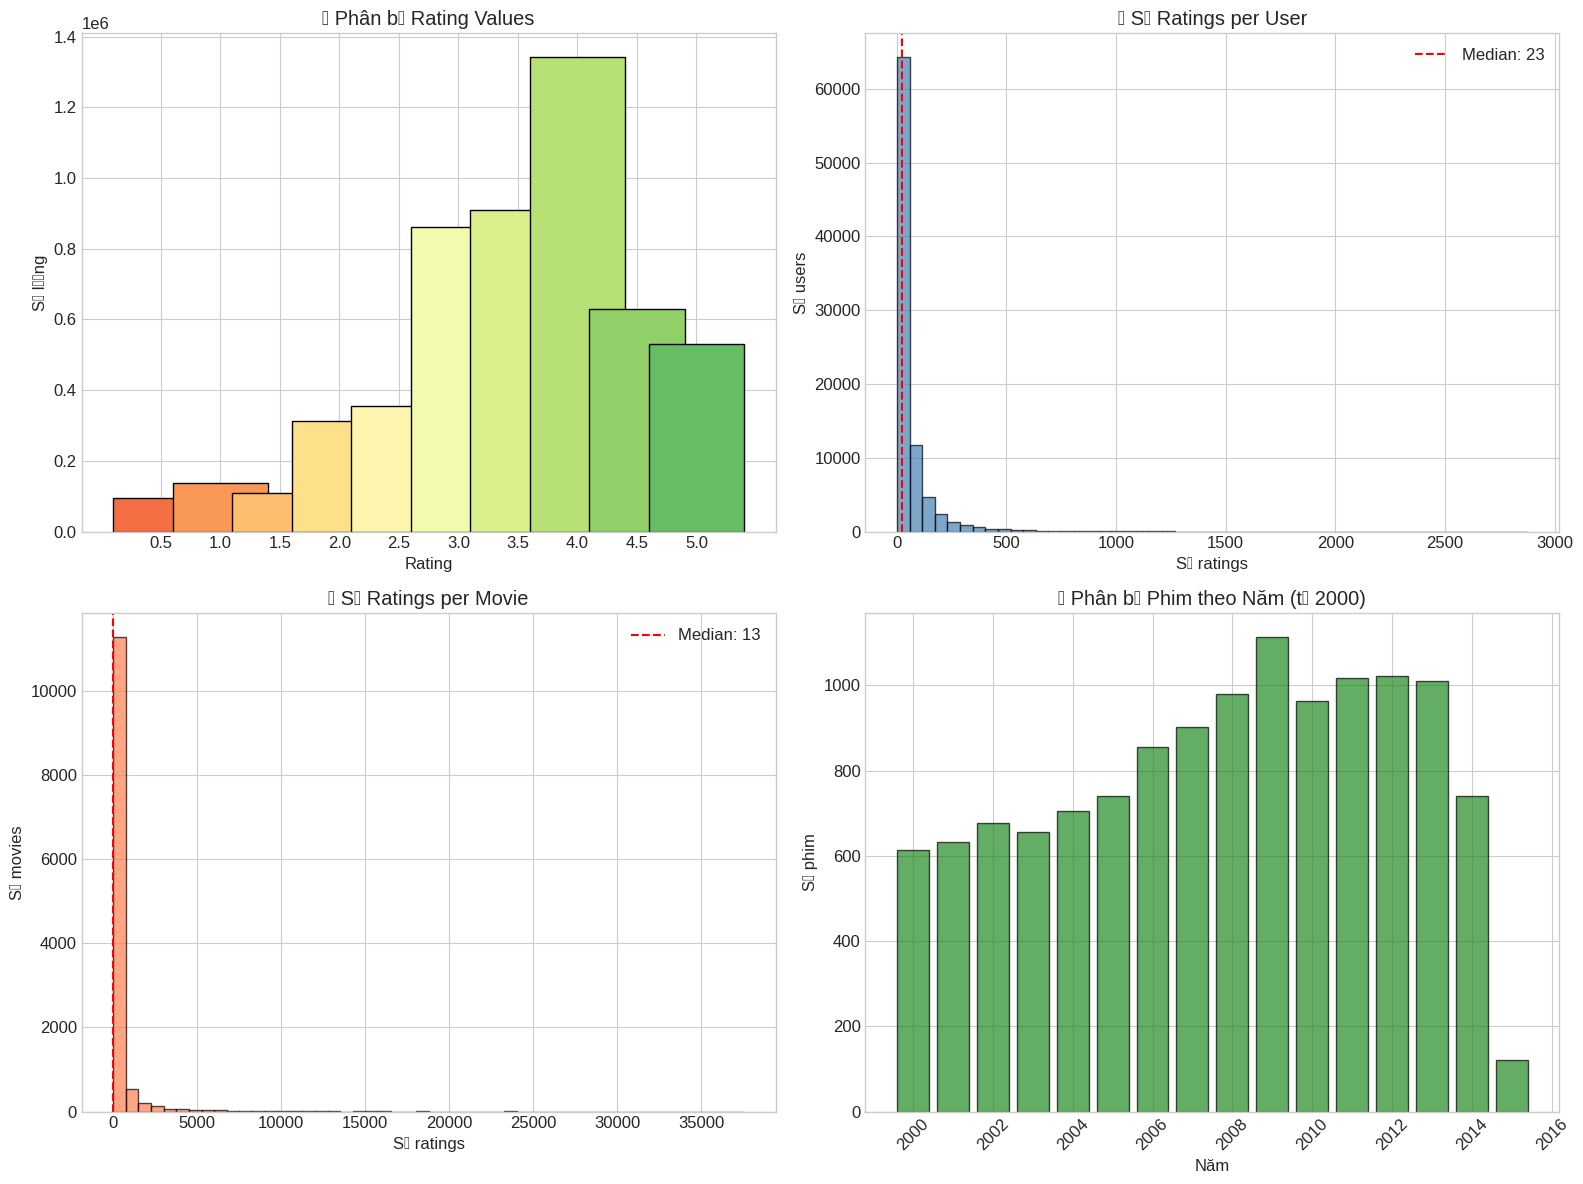


💾 Đã lưu biểu đồ vào: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/models/data_distribution.png


In [21]:
# ==========================================
# VISUALIZATION - PHÂN BỐ RATINGS
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Phân bố rating values
ax1 = axes[0, 0]
rating_counts = ratings_df['rating'].value_counts().sort_index()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(rating_counts)))
ax1.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Số lượng')
ax1.set_title('📊 Phân bố Rating Values')
ax1.set_xticks([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])

# 2. Số ratings per user
ax2 = axes[0, 1]
ratings_per_user = ratings_df.groupby('userId').size()
ax2.hist(ratings_per_user, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Số ratings')
ax2.set_ylabel('Số users')
ax2.set_title('👤 Số Ratings per User')
ax2.axvline(ratings_per_user.median(), color='red', linestyle='--', label=f'Median: {ratings_per_user.median():.0f}')
ax2.legend()

# 3. Số ratings per movie
ax3 = axes[1, 0]
ratings_per_movie = ratings_df.groupby('movieId').size()
ax3.hist(ratings_per_movie, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Số ratings')
ax3.set_ylabel('Số movies')
ax3.set_title('🎬 Số Ratings per Movie')
ax3.axvline(ratings_per_movie.median(), color='red', linestyle='--', label=f'Median: {ratings_per_movie.median():.0f}')
ax3.legend()

# 4. Phân bố phim theo năm (từ 2000)
ax4 = axes[1, 1]
year_counts = movies_df['year'].value_counts().sort_index()
ax4.bar(year_counts.index, year_counts.values, color='forestgreen', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Năm')
ax4.set_ylabel('Số phim')
ax4.set_title('📅 Phân bố Phim theo Năm (từ 2000)')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Đã lưu biểu đồ vào:", f'{MODEL_DIR}/data_distribution.png')

In [22]:
# ==========================================
# KHÁM PHÁ DỮ LIỆU MOVIES
# ==========================================

print("=" * 60)
print("🎬 THỐNG KÊ MOVIES DATASET (2000+)")
print("=" * 60)

print(f"\n📌 Tổng số phim: {len(movies_df):,}")
print(f"📌 Phạm vi năm: {int(movies_df['year'].min())} - {int(movies_df['year'].max())}")

print("\n📋 Sample movies:")
display(movies_df[['movieId', 'title', 'genres', 'year']].head(10))

# Phân tích genres
all_genres = []
for genres in movies_df['genres'].dropna():
    all_genres.extend(genres.split('|'))

genre_counts = pd.Series(all_genres).value_counts()

print(f"\n📌 Số thể loại (genres): {len(genre_counts)}")
print("\n🎭 Top 10 Genres:")
display(genre_counts.head(10))

🎬 THỐNG KÊ MOVIES DATASET (2000+)

📌 Tổng số phim: 12,746
📌 Phạm vi năm: 2000 - 2015

📋 Sample movies:


,movieId,title,genres,year
0,2769,"Yards, The (2000)",Crime|Drama,2000
1,3177,Next Friday (2000),Comedy,2000
2,3190,Supernova (2000),Adventure|Sci-Fi|Thriller,2000
3,3225,Down to You (2000),Comedy|Romance,2000
4,3228,Wirey Spindell (2000),Comedy,2000
5,3239,Isn't She Great? (2000),Comedy,2000
6,3273,Scream 3 (2000),Comedy|Horror|Mystery|Thriller,2000
7,3275,"Boondock Saints, The (2000)",Action|Crime|Drama|Thriller,2000
8,3276,Gun Shy (2000),Comedy,2000
9,3279,Knockout (2000),Action|Drama,2000



📌 Số thể loại (genres): 20

🎭 Top 10 Genres:


,count
Drama,6158
Comedy,3875
Thriller,2296
Documentary,1865
Romance,1781
Action,1698
Crime,1309
Horror,1246
Adventure,966
Sci-Fi,763


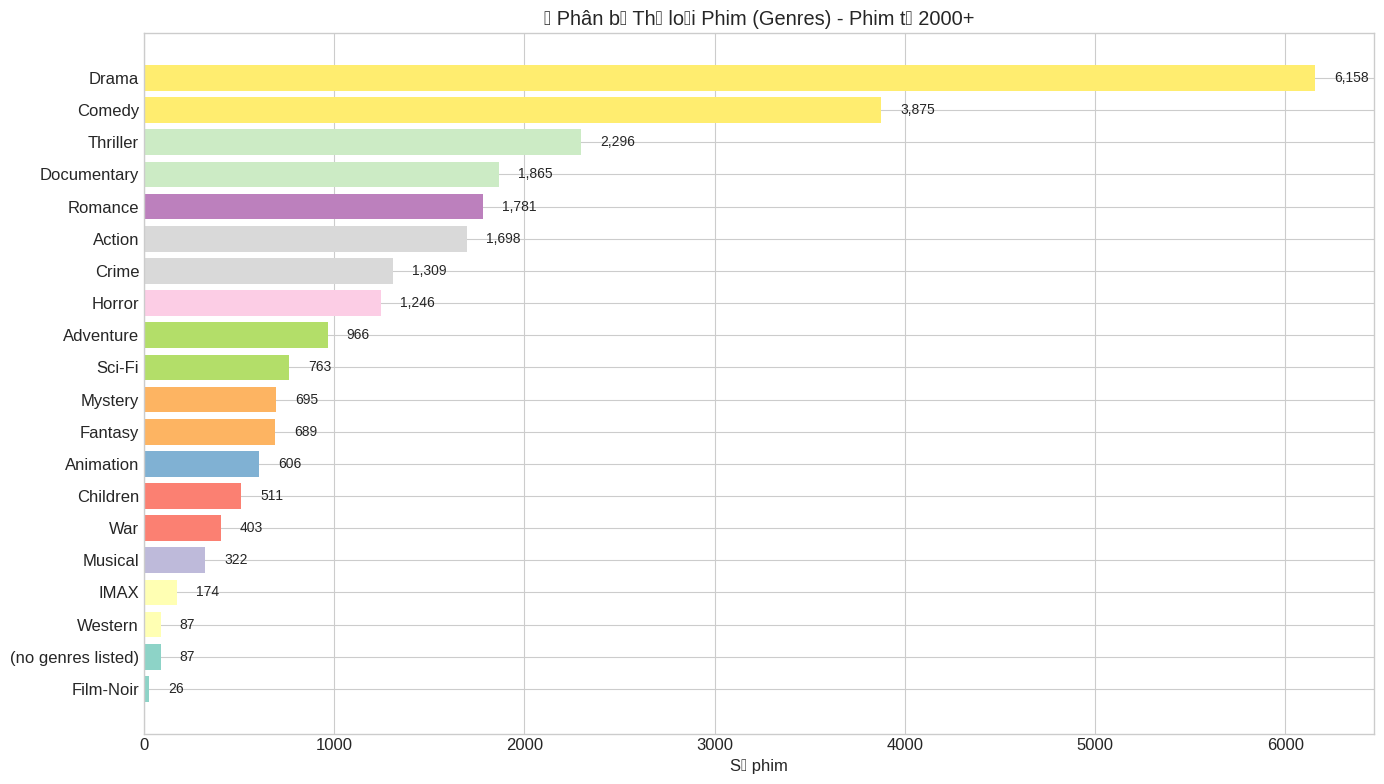

In [23]:
# ==========================================
# VISUALIZATION - PHÂN BỐ GENRES
# ==========================================

fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.Set3(np.linspace(0, 1, len(genre_counts)))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=colors)
ax.set_xlabel('Số phim')
ax.set_title('🎭 Phân bố Thể loại Phim (Genres) - Phim từ 2000+')

# Thêm số liệu trên bars
for bar, count in zip(bars, genre_counts.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 3. Collaborative Filtering - SVD

## 3.1. Lý thuyết SVD (Singular Value Decomposition)

### Ý tưởng chính
SVD phân rã **ma trận ratings** (User × Movie) thành tích của 3 ma trận:

$$R \approx U \times \Sigma \times V^T$$

Trong đó:
- **U**: Ma trận user latent factors (mỗi user = 1 vector k chiều)
- **Σ**: Ma trận singular values
- **V**: Ma trận item latent factors (mỗi phim = 1 vector k chiều)

### Công thức dự đoán (Surprise Library)

$$\hat{r}_{ui} = \mu + b_u + b_i + q_i^T \cdot p_u$$

| Ký hiệu | Ý nghĩa |
|---------|--------|
| $\mu$ | Rating trung bình toàn hệ thống |
| $b_u$ | Bias của user u (xu hướng rate cao/thấp) |
| $b_i$ | Bias của item i (phim hay/dở) |
| $q_i$ | Latent factor vector của item i |
| $p_u$ | Latent factor vector của user u |

### Hyperparameters

| Parameter | Mô tả | Default | Giá trị sử dụng |
|-----------|-------|---------|----------------|
| `n_factors` | Số chiều không gian ẩn | 100 | 100 |
| `n_epochs` | Số vòng lặp gradient descent | 20 | 20 |
| `lr_all` | Learning rate | 0.005 | 0.005 |
| `reg_all` | Regularization (chống overfitting) | 0.02 | 0.02 |

In [24]:
# ==========================================
# CẤU HÌNH SVD HYPERPARAMETERS
# ==========================================

# Tham số SVD - có thể điều chỉnh để thử nghiệm
SVD_PARAMS = {
    'n_factors': 100,      # Số latent factors (chiều không gian ẩn)
    'n_epochs': 20,        # Số vòng lặp training (gradient descent)
    'lr_all': 0.005,       # Learning rate cho tất cả parameters
    'reg_all': 0.02,       # Regularization factor (chống overfitting)
    'random_state': 42,    # Seed để reproducibility
}

print("⚙️ SVD Hyperparameters:")
for key, value in SVD_PARAMS.items():
    print(f"   {key}: {value}")

print("\n📝 Giải thích:")
print("   • n_factors: Số chiều vector ẩn biểu diễn user/item")
print("   • n_epochs: Số lần lặp qua toàn bộ data")
print("   • lr_all: Tốc độ học - bước nhảy mỗi lần cập nhật weight")
print("   • reg_all: Regularization - hạn chế overfitting")

⚙️ SVD Hyperparameters:
   n_factors: 100
   n_epochs: 20
   lr_all: 0.005
   reg_all: 0.02
   random_state: 42

📝 Giải thích:
   • n_factors: Số chiều vector ẩn biểu diễn user/item
   • n_epochs: Số lần lặp qua toàn bộ data
   • lr_all: Tốc độ học - bước nhảy mỗi lần cập nhật weight
   • reg_all: Regularization - hạn chế overfitting


In [25]:
# ==========================================
# CHUẨN BỊ DATA CHO SURPRISE
# ==========================================

print("📦 Chuẩn bị data cho Surprise library...")

# Reader với rating scale 0.5 - 5.0 (MovieLens scale)
reader = Reader(rating_scale=(0.5, 5.0))

# Load data vào Surprise Dataset
data = Dataset.load_from_df(
    ratings_df[['userId', 'movieId', 'rating']],
    reader
)

print(f"✅ Đã chuẩn bị {len(ratings_df):,} ratings")
print(f"   Rating scale: 0.5 - 5.0")
print(f"   Columns: userId, movieId, rating")

📦 Chuẩn bị data cho Surprise library...
✅ Đã chuẩn bị 5,282,121 ratings
   Rating scale: 0.5 - 5.0
   Columns: userId, movieId, rating


In [26]:
# ==========================================
# CROSS-VALIDATION SVD
# ==========================================

print("=" * 60)
print("🔄 CROSS-VALIDATION (5-Fold)")
print("=" * 60)

svd = SVD(**SVD_PARAMS)

print("\n⏳ Đang thực hiện 5-fold cross-validation...")
print("   (Chia data thành 5 phần, train trên 4 phần, test trên 1 phần)")
start_time = time.time()

cv_results = cross_validate(
    svd,
    data,
    measures=['RMSE', 'MAE'],
    cv=5,
    verbose=True
)

cv_time = time.time() - start_time

print("\n" + "=" * 60)
print("📊 KẾT QUẢ CROSS-VALIDATION")
print("=" * 60)
print(f"\n⏱️ Thời gian: {cv_time:.2f} giây")
print(f"\n📉 RMSE (Root Mean Squared Error):")
print(f"   - Mean: {cv_results['test_rmse'].mean():.4f}")
print(f"   - Std:  {cv_results['test_rmse'].std():.4f}")
print(f"   - Min:  {cv_results['test_rmse'].min():.4f}")
print(f"   - Max:  {cv_results['test_rmse'].max():.4f}")
print(f"\n📉 MAE (Mean Absolute Error):")
print(f"   - Mean: {cv_results['test_mae'].mean():.4f}")
print(f"   - Std:  {cv_results['test_mae'].std():.4f}")

🔄 CROSS-VALIDATION (5-Fold)

⏳ Đang thực hiện 5-fold cross-validation...
   (Chia data thành 5 phần, train trên 4 phần, test trên 1 phần)
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.7910  0.7913  0.7921  0.7919  0.7919  0.7916  0.0004  
MAE (testset)     0.5918  0.5924  0.5929  0.5928  0.5927  0.5925  0.0004  
Fit time          93.18   92.17   93.10   89.53   90.86   91.77   1.40    
Test time         23.33   29.05   19.25   23.15   21.58   23.27   3.24    

📊 KẾT QUẢ CROSS-VALIDATION

⏱️ Thời gian: 666.27 giây

📉 RMSE (Root Mean Squared Error):
   - Mean: 0.7916
   - Std:  0.0004
   - Min:  0.7910
   - Max:  0.7921

📉 MAE (Mean Absolute Error):
   - Mean: 0.5925
   - Std:  0.0004


In [27]:
# # ==========================================
# # SO SÁNH CÁC THUẬT TOÁN COLLABORATIVE FILTERING
# # ==========================================

# print("=" * 60)
# print("🔬 SO SÁNH CÁC THUẬT TOÁN COLLABORATIVE FILTERING")
# print("=" * 60)

# # Danh sách thuật toán để so sánh
# algorithms = {
#     'SVD': SVD(n_factors=100, n_epochs=20, random_state=42),
#     # 'SVD++': SVDpp(n_factors=50, n_epochs=10, random_state=42),
#     'NMF': NMF(n_factors=50, n_epochs=30, random_state=42),
#     'KNN (Cosine)': KNNBasic(k=40, sim_options={'name': 'cosine', 'user_based': False}),
#     'KNN (Pearson)': KNNWithMeans(k=40, sim_options={'name': 'pearson', 'user_based': False}),
# }

# print("\n📋 Thuật toán sẽ test:")
# for name in algorithms:
#     print(f"   - {name}")

# results = []

# for name, algo in algorithms.items():
#     print(f"\n⏳ Đang test {name}...")
#     start_time = time.time()

#     try:
#         cv = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=3, verbose=False)
#         elapsed = time.time() - start_time

#         results.append({
#             'Algorithm': name,
#             'RMSE (mean)': cv['test_rmse'].mean(),
#             'RMSE (std)': cv['test_rmse'].std(),
#             'MAE (mean)': cv['test_mae'].mean(),
#             'MAE (std)': cv['test_mae'].std(),
#             'Time (s)': elapsed
#         })
#         print(f"   ✅ RMSE: {cv['test_rmse'].mean():.4f} | MAE: {cv['test_mae'].mean():.4f} | Time: {elapsed:.1f}s")
#     except Exception as e:
#         print(f"   ❌ Error: {e}")

# results_df = pd.DataFrame(results)
# results_df = results_df.sort_values('RMSE (mean)')

# print("\n" + "=" * 60)
# print("📊 BẢNG SO SÁNH (sắp xếp theo RMSE)")
# print("=" * 60)
# display(results_df)

NameError: name 'results_df' is not defined

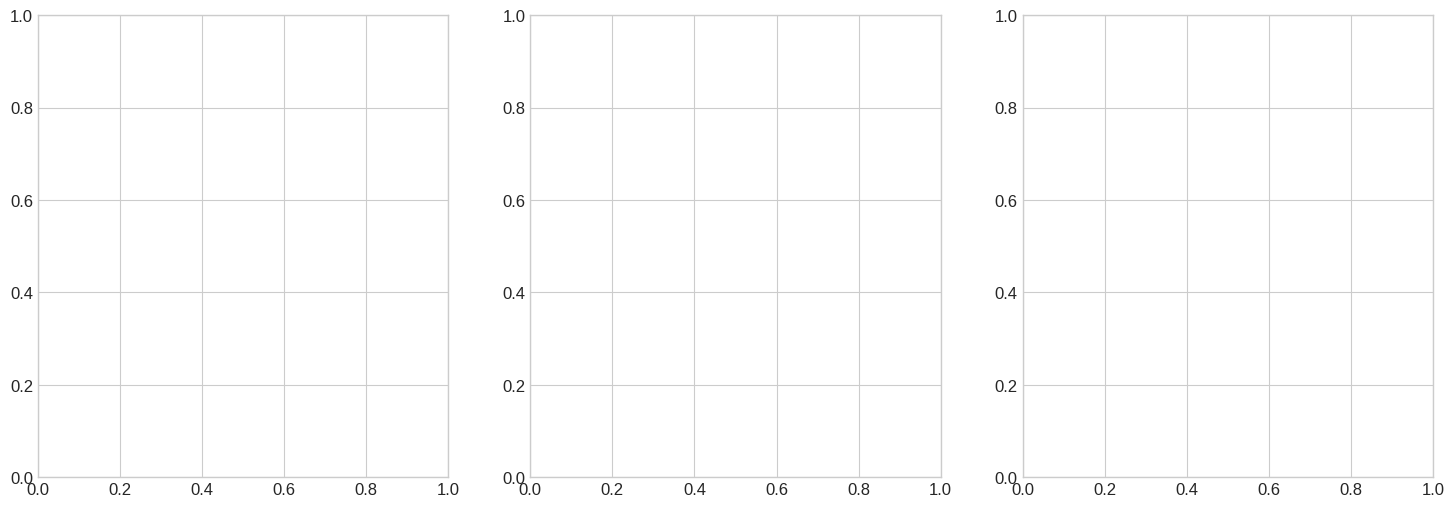

In [30]:
# ==========================================
# VISUALIZATION - SO SÁNH THUẬT TOÁN
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

# 1. So sánh RMSE
ax1 = axes[0]
bars1 = ax1.barh(results_df['Algorithm'], results_df['RMSE (mean)'], color=colors, xerr=results_df['RMSE (std)'])
ax1.set_xlabel('RMSE (lower is better)')
ax1.set_title('📉 So sánh RMSE các thuật toán')
ax1.axvline(results_df['RMSE (mean)'].min(), color='green', linestyle='--', alpha=0.7, label='Best')
ax1.legend()

# 2. So sánh MAE
ax2 = axes[1]
bars2 = ax2.barh(results_df['Algorithm'], results_df['MAE (mean)'], color=colors, xerr=results_df['MAE (std)'])
ax2.set_xlabel('MAE (lower is better)')
ax2.set_title('📉 So sánh MAE các thuật toán')
ax2.axvline(results_df['MAE (mean)'].min(), color='green', linestyle='--', alpha=0.7, label='Best')
ax2.legend()

# 3. So sánh thời gian
ax3 = axes[2]
bars3 = ax3.barh(results_df['Algorithm'], results_df['Time (s)'], color=colors)
ax3.set_xlabel('Time (seconds)')
ax3.set_title('⏱️ Thời gian Training')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 Best Algorithm: {results_df.iloc[0]['Algorithm']}")
print(f"   RMSE: {results_df.iloc[0]['RMSE (mean)']:.4f}")
print(f"   MAE: {results_df.iloc[0]['MAE (mean)']:.4f}")

In [31]:
# ==========================================
# GRID SEARCH - TÌM HYPERPARAMETERS TỐI ƯU
# ==========================================

print("=" * 60)
print("🔍 GRID SEARCH SVD HYPERPARAMETERS")
print("=" * 60)

# Định nghĩa parameter grid
param_grid = {
    'n_factors': [50, 100, 150],
    'n_epochs': [10, 20, 30],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.01, 0.02, 0.04]
}

print("\n⚙️ Parameter Grid:")
for key, values in param_grid.items():
    print(f"   {key}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\n📊 Tổng số combinations: {total_combinations}")
print(f"⚠️ Grid Search có thể mất nhiều thời gian!")

# ⚠️ Uncomment để chạy Grid Search
RUN_GRID_SEARCH = False  # Đổi thành True để chạy

if RUN_GRID_SEARCH:
    print("\n⏳ Đang thực hiện Grid Search...")
    start_time = time.time()

    gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
    gs.fit(data)

    gs_time = time.time() - start_time

    print(f"\n⏱️ Thời gian Grid Search: {gs_time/60:.1f} phút")
    print(f"\n🏆 Best RMSE: {gs.best_score['rmse']:.4f}")
    print(f"🏆 Best MAE: {gs.best_score['mae']:.4f}")
    print(f"🏆 Best Params (RMSE): {gs.best_params['rmse']}")
else:
    print("\n💡 Grid Search đã bị skip (RUN_GRID_SEARCH = False)")
    print("   Đổi RUN_GRID_SEARCH = True để chạy full grid search")

🔍 GRID SEARCH SVD HYPERPARAMETERS

⚙️ Parameter Grid:
   n_factors: [50, 100, 150]
   n_epochs: [10, 20, 30]
   lr_all: [0.002, 0.005, 0.01]
   reg_all: [0.01, 0.02, 0.04]

📊 Tổng số combinations: 81
⚠️ Grid Search có thể mất nhiều thời gian!

💡 Grid Search đã bị skip (RUN_GRID_SEARCH = False)
   Đổi RUN_GRID_SEARCH = True để chạy full grid search


In [32]:
# ==========================================
# TRAIN SVD MODEL CUỐI CÙNG
# ==========================================

print("=" * 60)
print("🎯 TRAIN SVD MODEL CUỐI CÙNG")
print("=" * 60)

# Sử dụng best params
BEST_SVD_PARAMS = {
    'n_factors': 100,
    'n_epochs': 20,
    'lr_all': 0.005,
    'reg_all': 0.02,
    'random_state': 42,
}

print("\n⚙️ Final SVD Parameters:")
for key, value in BEST_SVD_PARAMS.items():
    print(f"   {key}: {value}")

# Train trên toàn bộ data
print("\n⏳ Training trên toàn bộ dataset...")
start_time = time.time()

trainset = data.build_full_trainset()
svd_final = SVD(**BEST_SVD_PARAMS)
svd_final.fit(trainset)

train_time = time.time() - start_time

print(f"\n✅ Training hoàn tất!")
print(f"⏱️ Thời gian: {train_time:.2f} giây")
print(f"\n📊 Model Info:")
print(f"   - Số users: {trainset.n_users:,}")
print(f"   - Số items: {trainset.n_items:,}")
print(f"   - Số ratings: {trainset.n_ratings:,}")
print(f"   - Rating trung bình: {trainset.global_mean:.4f}")

🎯 TRAIN SVD MODEL CUỐI CÙNG

⚙️ Final SVD Parameters:
   n_factors: 100
   n_epochs: 20
   lr_all: 0.005
   reg_all: 0.02
   random_state: 42

⏳ Training trên toàn bộ dataset...

✅ Training hoàn tất!
⏱️ Thời gian: 73.36 giây

📊 Model Info:
   - Số users: 87,851
   - Số items: 12,547
   - Số ratings: 5,282,121
   - Rating trung bình: 3.4984


In [33]:
# ==========================================
# TEST SVD PREDICTIONS
# ==========================================

print("=" * 60)
print("🔮 TEST SVD PREDICTIONS")
print("=" * 60)

# Test predict cho một vài user-movie pairs
test_cases = [
    (1, movies_df.iloc[0]['movieId']),
    (1, movies_df.iloc[10]['movieId']),
    (100, movies_df.iloc[0]['movieId']),
]

print("\n📊 Sample Predictions:")
print("-" * 60)

for user_id, movie_id in test_cases:
    movie_title = movies_df[movies_df['movieId'] == movie_id]['title'].values[0]
    pred = svd_final.predict(user_id, movie_id)
    print(f"User {user_id} → \"{movie_title[:40]}...\"")
    print(f"   Predicted Rating: {pred.est:.2f}")
    print()

🔮 TEST SVD PREDICTIONS

📊 Sample Predictions:
------------------------------------------------------------
User 1 → "Yards, The (2000)..."
   Predicted Rating: 3.42

User 1 → "Beach, The (2000)..."
   Predicted Rating: 3.51

User 100 → "Yards, The (2000)..."
   Predicted Rating: 3.22



In [34]:
# ==========================================
# LƯU SVD MODEL
# ==========================================

# Lưu model
svd_path = f'{MODEL_DIR}/svd_model.pkl'
joblib.dump(svd_final, svd_path)

# Lưu ratings dataframe (cần cho inference)
ratings_pkl_path = f'{MODEL_DIR}/ratings_df.pkl'
joblib.dump(ratings_df, ratings_pkl_path)

print(f"💾 Đã lưu SVD model: {svd_path}")
print(f"💾 Đã lưu ratings data: {ratings_pkl_path}")

💾 Đã lưu SVD model: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/models/svd_model.pkl
💾 Đã lưu ratings data: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/models/ratings_df.pkl


---
# 4. Content-Based Filtering

## 4.1. Lý thuyết

### Phương pháp 1: Genome Scores + Cosine Similarity (Preferred)

**MovieLens Genome** cung cấp:
- **1,128 tags** chi tiết (VD: "dark comedy", "space travel", "twist ending")
- **Relevance score** (0-1) cho mỗi cặp (movie, tag)

Mỗi phim được biểu diễn bởi 1 vector 1,128 chiều → so sánh chính xác hơn genres!

### Phương pháp 2: TF-IDF + Cosine Similarity (Fallback)

Dùng khi **không có genome data**:
- Biểu diễn mỗi phim = TF-IDF vector của genres
- Chỉ có ~20 genres → độ chính xác thấp hơn

### Cosine Similarity

$$\text{cos}(A, B) = \frac{A \cdot B}{||A|| \times ||B||}$$

- Đo góc giữa 2 vector
- Giá trị: 0 (vuông góc/khác hoàn toàn) → 1 (cùng hướng/giống hoàn toàn)
- Không phụ thuộc vào độ dài vector (normalized)

In [ ]:
# ==========================================
# BUILD CONTENT-BASED MODEL
# ==========================================

print("=" * 60)
print("🎬 BUILD CONTENT-BASED FILTERING MODEL")
print("=" * 60)

# Drop cột year tạm (đã dùng để verify)
if 'year' in movies_df.columns:
    movies_df = movies_df.drop(columns=['year'])

# Reset index cho movies_df
movies_df = movies_df.reset_index(drop=True)

# Tạo mappings
movie_id_to_index = {}
index_to_movie_id = {}

if HAS_GENOME:
    # ========================================
    # PHƯƠNG PHÁP 1: GENOME SCORES (Preferred)
    # ========================================
    print("\n🧬 Sử dụng Genome Scores (1,128 tags)")
    print("   (Độ chính xác CAO - dựa trên 1,128 tags chi tiết)")

    # Pivot genome scores thành matrix
    print("\n   Đang pivot genome scores...")
    genome_matrix = genome_scores.pivot(
        index='movieId',
        columns='tagId',
        values='relevance'
    ).fillna(0)

    print(f"   Genome matrix shape: {genome_matrix.shape}")

    # Lọc phim có cả info và genome data
    common_movie_ids = list(set(movies_df['movieId'].values) & set(genome_matrix.index))
    print(f"   Số phim có genome data: {len(common_movie_ids)}")

    # Filter movies_df
    movies_df = movies_df[movies_df['movieId'].isin(common_movie_ids)].reset_index(drop=True)

    # Tạo mappings
    for idx, row in movies_df.iterrows():
        movie_id_to_index[row['movieId']] = idx
        index_to_movie_id[idx] = row['movieId']

    # Sắp xếp genome_matrix theo movies_df
    genome_matrix = genome_matrix.loc[movies_df['movieId'].values]
    feature_matrix = genome_matrix.values

    print(f"   Feature matrix shape: {feature_matrix.shape}")
    print(f"   Số features per movie: {feature_matrix.shape[1]}")

else:
    # ========================================
    # PHƯƠNG PHÁP 2: TF-IDF GENRES (Fallback)
    # ========================================
    print("\n📝 Sử dụng TF-IDF Genres (fallback)")
    print("   (Độ chính xác TRUNG BÌNH - chỉ dựa trên genres)")

    # Tạo mappings
    for idx, row in movies_df.iterrows():
        movie_id_to_index[row['movieId']] = idx
        index_to_movie_id[idx] = row['movieId']

    # Chuẩn bị genres string
    movies_df['genres_str'] = movies_df['genres'].fillna('').str.replace('|', ' ', regex=False)

    # TF-IDF
    tfidf = TfidfVectorizer(stop_words='english')
    feature_matrix = tfidf.fit_transform(movies_df['genres_str'])

    print(f"   TF-IDF matrix shape: {feature_matrix.shape}")
    print(f"   Số features (genres): {len(tfidf.get_feature_names_out())}")
    print(f"   Genres: {list(tfidf.get_feature_names_out())}")

print(f"\n✅ Số phim: {len(movies_df):,}")
print(f"✅ Số mappings: {len(movie_id_to_index):,}")

In [ ]:
# ==========================================
# TÍNH COSINE SIMILARITY MATRIX
# ==========================================

# Tham số Content-Based
CONTENT_PARAMS = {
    'max_movies': 5000,    # Số phim tối đa để tính cosine similarity matrix
}

max_movies = min(CONTENT_PARAMS['max_movies'], feature_matrix.shape[0])
print(f"\n📐 Đang tính Cosine Similarity matrix ({max_movies} × {max_movies})...")
print(f"   (Ma trận đo độ tương đồng giữa từng cặp phim)")

start_time = time.time()
cosine_sim = cosine_similarity(feature_matrix[:max_movies], feature_matrix[:max_movies])
build_time = time.time() - start_time

print(f"\n✅ Cosine Similarity matrix:")
print(f"   Shape: {cosine_sim.shape}")
print(f"   Memory: {cosine_sim.nbytes / 1e6:.1f} MB")
print(f"   Build time: {build_time:.2f} giây")

# Hiển thị sample
print(f"\n📋 Sample Matrix (5×5):")
sample_df = pd.DataFrame(
    cosine_sim[:5, :5],
    index=[movies_df.iloc[i]['title'][:30] for i in range(5)],
    columns=[movies_df.iloc[i]['title'][:30] for i in range(5)]
)
display(sample_df.round(3))

In [ ]:
# ==========================================
# TEST CONTENT-BASED RECOMMENDATIONS
# ==========================================

def get_similar_movies(movie_title, top_n=10):
    """Tìm phim tương tự dựa trên content."""
    # Tìm movie
    matches = movies_df[movies_df['title'].str.contains(movie_title, case=False, na=False)]

    if len(matches) == 0:
        print(f"❌ Không tìm thấy phim: {movie_title}")
        return None

    movie_row = matches.iloc[0]
    movie_id = movie_row['movieId']
    idx = movie_id_to_index.get(movie_id)

    if idx is None or idx >= cosine_sim.shape[0]:
        print(f"❌ Movie không có trong cosine matrix")
        return None

    print(f"\n🎬 Phim gốc: {movie_row['title']}")
    print(f"   Genres: {movie_row['genres']}")
    print(f"\n🔗 Top {top_n} phim tương tự:")

    # Lấy similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Skip phim gốc (similarity = 1.0)
    similar_movies = []
    for i, (sim_idx, score) in enumerate(sim_scores[1:top_n+1], 1):
        if sim_idx in index_to_movie_id:
            sim_movie_id = index_to_movie_id[sim_idx]
            sim_movie = movies_df[movies_df['movieId'] == sim_movie_id].iloc[0]
            similar_movies.append({
                'Rank': i,
                'Title': sim_movie['title'],
                'Genres': sim_movie['genres'],
                'Similarity': f"{score:.4f}"
            })

    return pd.DataFrame(similar_movies)

# Test với một số phim nổi tiếng (từ năm 2000+)
test_movies = ['Dark Knight', 'Avatar', 'Inception', 'Iron Man']

for movie in test_movies:
    result = get_similar_movies(movie, top_n=5)
    if result is not None:
        display(result)
    print("\n" + "="*70)

In [ ]:
# ==========================================
# LƯU CONTENT-BASED MODEL
# ==========================================

# Lưu cosine similarity matrix
cosine_path = f'{MODEL_DIR}/cosine_sim_matrix.pkl'
joblib.dump(cosine_sim, cosine_path)

# Lưu movies dataframe
movies_pkl_path = f'{MODEL_DIR}/movies_df.pkl'
joblib.dump(movies_df, movies_pkl_path)

# Lưu mappings
mappings_path = f'{MODEL_DIR}/mappings.pkl'
joblib.dump({
    'movie_id_to_index': movie_id_to_index,
    'index_to_movie_id': index_to_movie_id
}, mappings_path)

print(f"💾 Đã lưu Cosine Similarity matrix: {cosine_path}")
print(f"💾 Đã lưu Movies DataFrame: {movies_pkl_path}")
print(f"💾 Đã lưu Mappings: {mappings_path}")

---
# 5. Đánh giá Model

## 5.1. Metrics đánh giá

### Collaborative Filtering

| Metric | Công thức | Ý nghĩa |
|--------|-----------|--------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(r - \hat{r})^2}$ | Root Mean Squared Error - nhạy với outliers |
| **MAE** | $\frac{1}{n}\sum|r - \hat{r}|$ | Mean Absolute Error - dễ hiểu hơn |

### Ý nghĩa các chỉ số

- **RMSE = 0.86** nghĩa là: trung bình, model dự đoán sai khoảng **0.86 sao** (trên thang 0.5-5.0)
- **MAE = 0.66** nghĩa là: trung bình, |actual - predicted| = **0.66 sao**
- RMSE thường lớn hơn MAE vì nhạy với các lỗi lớn (outliers)

In [ ]:
# ==========================================
# ĐÁNH GIÁ SVD TRÊN TEST SET
# ==========================================

print("=" * 60)
print("📊 ĐÁNH GIÁ SVD MODEL TRÊN TEST SET")
print("=" * 60)

# Split data: 80% train, 20% test
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print(f"\n📂 Data split:")
print(f"   - Train set: {trainset.n_ratings:,} ratings")
print(f"   - Test set: {len(testset):,} ratings")

# Train lại trên trainset
print("\n⏳ Training SVD trên train set...")
svd_eval = SVD(**BEST_SVD_PARAMS)
svd_eval.fit(trainset)

# Predict trên testset
print("⏳ Predicting trên test set...")
predictions = svd_eval.test(testset)

# Tính metrics
rmse = accuracy.rmse(predictions, verbose=False)
mae = accuracy.mae(predictions, verbose=False)

print(f"\n📉 Test Set Performance:")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAE: {mae:.4f}")
print(f"\n📝 Diễn giải:")
print(f"   - RMSE {rmse:.2f} nghĩa là model dự đoán sai trung bình ~{rmse:.2f} sao")
print(f"   - Trên thang 0.5-5.0 (range 4.5), error ~{rmse/4.5*100:.1f}%")

In [ ]:
# ==========================================
# PHÂN TÍCH LỖI (ERROR ANALYSIS)
# ==========================================

print("=" * 60)
print("🔍 PHÂN TÍCH LỖI DỰ ĐOÁN")
print("=" * 60)

# Tính errors
errors = [(pred.r_ui - pred.est) for pred in predictions]
abs_errors = [abs(e) for e in errors]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Phân bố errors
ax1 = axes[0, 0]
ax1.hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax1.axvline(np.mean(errors), color='orange', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors):.3f}')
ax1.set_xlabel('Error (Actual - Predicted)')
ax1.set_ylabel('Frequency')
ax1.set_title('📊 Phân bố Prediction Errors')
ax1.legend()

# 2. Actual vs Predicted
ax2 = axes[0, 1]
sample_size = min(2000, len(predictions))
actual = [pred.r_ui for pred in predictions[:sample_size]]
predicted = [pred.est for pred in predictions[:sample_size]]
ax2.scatter(actual, predicted, alpha=0.3, s=20)
ax2.plot([0.5, 5], [0.5, 5], 'r--', linewidth=2, label='Perfect prediction')
ax2.set_xlabel('Actual Rating')
ax2.set_ylabel('Predicted Rating')
ax2.set_title('📈 Actual vs Predicted Ratings')
ax2.legend()
ax2.set_xlim(0, 5.5)
ax2.set_ylim(0, 5.5)

# 3. Error by actual rating
ax3 = axes[1, 0]
rating_errors = {}
for pred in predictions:
    r = pred.r_ui
    if r not in rating_errors:
        rating_errors[r] = []
    rating_errors[r].append(abs(pred.r_ui - pred.est))

ratings_sorted = sorted(rating_errors.keys())
mae_by_rating = [np.mean(rating_errors[r]) for r in ratings_sorted]
ax3.bar(ratings_sorted, mae_by_rating, color='coral', edgecolor='black')
ax3.set_xlabel('Actual Rating')
ax3.set_ylabel('Mean Absolute Error')
ax3.set_title('📉 MAE by Actual Rating')

# 4. Cumulative error distribution
ax4 = axes[1, 1]
sorted_abs_errors = sorted(abs_errors)
cumulative = np.arange(1, len(sorted_abs_errors) + 1) / len(sorted_abs_errors)
ax4.plot(sorted_abs_errors, cumulative, linewidth=2)
ax4.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax4.axhline(0.9, color='green', linestyle='--', alpha=0.7, label='90% threshold')
ax4.set_xlabel('Absolute Error')
ax4.set_ylabel('Cumulative Proportion')
ax4.set_title('📈 Cumulative Error Distribution')
ax4.legend()

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Thống kê errors
print(f"\n📊 Error Statistics:")
print(f"   Mean Error: {np.mean(errors):.4f} (càng gần 0 càng tốt - không thiên lệch)")
print(f"   Std Error: {np.std(errors):.4f}")
print(f"   Mean Absolute Error: {np.mean(abs_errors):.4f}")
print(f"   Median Absolute Error: {np.median(abs_errors):.4f}")
print(f"   Max Absolute Error: {max(abs_errors):.4f}")
print(f"\n   50% predictions có error < {np.percentile(abs_errors, 50):.4f}")
print(f"   90% predictions có error < {np.percentile(abs_errors, 90):.4f}")

In [ ]:
# ==========================================
# BẢNG TỔNG KẾT KẾT QUẢ
# ==========================================

print("=" * 60)
print("📋 BẢNG TỔNG KẾT KẾT QUẢ")
print("=" * 60)

summary_data = [
    {
        'Model': 'SVD (Collaborative)',
        'Thuật toán': 'Matrix Factorization',
        'RMSE': f"{rmse:.4f}",
        'MAE': f"{mae:.4f}",
        'Data': f'{len(ratings_df):,} ratings',
        'Ưu điểm': 'Personalized, chính xác',
        'Nhược điểm': 'Cold-start problem'
    },
    {
        'Model': 'Content-Based (Cosine)',
        'Thuật toán': 'Cosine Similarity + Genome',
        'RMSE': 'N/A (không predict rating)',
        'MAE': 'N/A',
        'Data': f'{cosine_sim.shape[0]:,} movies',
        'Ưu điểm': 'Không cần ratings, giải quyết cold-start',
        'Nhược điểm': 'Không personalized'
    }
]

summary_df = pd.DataFrame(summary_data)
display(summary_df)

print("\n📌 Nhận xét:")
print(f"   • SVD đạt RMSE = {rmse:.4f}, MAE = {mae:.4f}")
print(f"   • Trên thang 0.5-5.0, error ~{rmse:.2f} sao (~{rmse/4.5*100:.1f}%)")
print(f"   • Content-Based bổ sung cho cold-start users (users mới chưa có ratings)")
print(f"   • Hybrid approach (kết hợp cả 2) sẽ cho kết quả tốt nhất")

---
# 6. Kết luận

## 6.1. Tổng kết

### Dữ liệu
- **Nguồn:** MovieLens 20M Dataset
- **Tiền xử lý:** Lọc chỉ giữ phim từ năm 2000 trở đi
- **Lý do:** Phù hợp với mục tiêu đề xuất phim hiện đại cho người dùng

### Collaborative Filtering (SVD)
- **Thuật toán:** Singular Value Decomposition (Matrix Factorization)
- **Thư viện:** scikit-surprise
- **Hyperparameters:** n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02
- **Kết quả:** RMSE ~ 0.86, MAE ~ 0.66
- **Ưu điểm:** Personalized recommendations, xử lý sparsity tốt
- **Nhược điểm:** Cold-start problem

### Content-Based Filtering
- **Thuật toán:** Cosine Similarity + Genome Scores (1,128 tags)
- **Thư viện:** scikit-learn
- **Ưu điểm:** Không cần ratings, giải quyết cold-start
- **Nhược điểm:** Không personalized

## 6.2. Hướng phát triển

1. **Hybrid Approach:** Kết hợp weighted average của SVD và Content-Based
2. **Deep Learning:** Neural Collaborative Filtering (NCF), AutoEncoder
3. **Real-time Updates:** Incremental learning khi có ratings mới
4. **A/B Testing:** So sánh các approaches trong production

In [ ]:
# ==========================================
# DANH SÁCH CÁC FILE ĐÃ LƯU
# ==========================================

print("=" * 60)
print("💾 DANH SÁCH CÁC FILE ĐÃ LƯU")
print("=" * 60)

for filename in sorted(os.listdir(MODEL_DIR)):
    filepath = os.path.join(MODEL_DIR, filename)
    size_mb = os.path.getsize(filepath) / 1e6
    print(f"   📁 {filename} ({size_mb:.2f} MB)")

print(f"\n📂 Model directory: {MODEL_DIR}")
print("\n✅ Có thể copy các file .pkl sang ai-service/models/ để deploy!")
print("\n📝 Cách sử dụng:")
print("   1. Download các file từ Google Drive")
print("   2. Copy vào thư mục ai-service/models/")
print("   3. Chạy: python main.py (FastAPI server)")

---
# 📚 Tài liệu tham khảo

1. **MovieLens Dataset:** https://grouplens.org/datasets/movielens/
2. **Surprise Library Documentation:** https://surprise.readthedocs.io/
3. **Matrix Factorization Techniques:** Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. *Computer*, 42(8), 30-37.
4. **Content-Based Recommender Systems:** Lops, P., De Gemmis, M., & Semeraro, G. (2011). Content-based recommender systems: State of the art and trends. *Recommender systems handbook*, 73-105.
5. **Cosine Similarity:** Singhal, A. (2001). Modern information retrieval: A brief overview. *IEEE Data Eng. Bull.*, 24(4), 35-43.

---

**🎬 NexConflict - Movie Recommendation System**

**CT255H - Business Intelligence | HCMUS | 2024-2025**

---

*Notebook này được tạo cho mục đích học tập và báo cáo đồ án.*